In [11]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [12]:
print("Текущая директория:", os.getcwd())
print("Файлы в текущей директории:", os.listdir())

Текущая директория: /home/arseniy/bioinformatics/Applications/SQ_project/Colocalization/Colocalization
Файлы в текущей директории: ['Colocalization_v2.ipynb', 'build_meta_v2.ipynb', 'gtdbtk_summary_all.csv', 'build_meta_ed.py', 'meta_table_merge.tsv', 'SQ_metatable_all_parts.tsv', 'Копия build_meta_ed.py', 'SQ_metatable_all_parts_with_clusters.tsv', 'unique_sq_hits_all.tsv', 'SQ_ref_proteins_filt.tsv', 'Colocalization_v3.ipynb', 'SQ_metatable_all_parts_v2.tsv', 'SQ_metatable_with_taxonomy.tsv', 'build_meta_v2.py']


In [13]:
SQ_ref_proteins = pd.read_csv('SQ_ref_proteins_filt.tsv', sep='\t')
SQ_ref_proteins

,Protein ID,Organism name,Locus,Gene,Function,PFAM ID,Reference
0,AAK90113.2,Agrobacterium fabrum str. C58,sulfo- ASMO,ssuE,flavin reductase,PF01613,https://doi.org/10.1073/pnas.2116022119
1,AAK90112.1,Agrobacterium fabrum str. C58,sulfo- ASMO,squF,glucose-6-dehydrogenase,PF00248,https://doi.org/10.1073/pnas.2116022119
2,AAK90111.1,Agrobacterium fabrum str. C58,sulfo- ASMO,squD,SQ monooxygenase,PF00296,https://doi.org/10.1073/pnas.2116022119
3,ANG62941.1,Marinobacterium aestuarii str.ST58-10,sulfo- ASDO,sqoD,SQ dioxygenase,PF02668,https://pmc.ncbi.nlm.nih.gov/articles/pmid/377...
4,WP_017967307.1,Rhizobium leguminosarum bv. trifoliiSRDI565,sulfo-ED,sedC,SG dehydratase,PF00920,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
5,WP_017967308.1,Rhizobium leguminosarum bv. trifolii SRDI565,sulfo-ED,sedD,KDSG aldolase,PF01081,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
6,WP_017967309.1,Rhizobium leguminosarum bv. trifolii SRDI565,sulfo-ED,sedB,SGL lactonase,PF08450,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
7,WP_017967310.1,Rhizobium leguminosarum bv. trifolii SRDI565,sulfo-ED,sedA,SQ dehydrogenase,PF13561,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
8,PRO65849.1,Alkalicoccus urumqiensis BZ-SZ-XJ18,sulfo-EMP,sqvB,SQ mutarotase,PF16161,https://zhaogroup.chbe.illinois.edu/publicatio...
9,PRO65851.1,Alkalicoccus urumqiensis BZ-SZ-XJ18,sulfo-EMP,sqvD,SQ isomerase,PF02952,https://zhaogroup.chbe.illinois.edu/publicatio...


In [14]:
meta_table = pd.read_csv('SQ_metatable_all_parts_v2.tsv', sep='\t')
meta_table

,MAG,query,target,identity,aln_len,evalue,bitscore,product,contig,start,end,taxonomy
0,GCA_902803065.1,AAK90112.1,GCA_902803065.1_CCEEBC_01630,28.9,201,3.600000e-09,55.5,Oxidoreductase,CADCOP010000322.1,7080,8081,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...
1,GCA_902803065.1,AAK90112.1,GCA_902803065.1_CCEEBC_01592,27.9,201,4.830000e-09,55.1,Oxidoreductase,CADCOP010000315.1,2222,3223,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...
2,GCA_902803055.1,AAK90112.1,GCA_902803055.1_MMPJKM_00615,27.5,182,4.970000e-06,45.8,Aryl-alcohol dehydrogenase (NADP(+)),CADCOR010000114.1,596,1555,d__Bacteria;p__Bacillota;c__Bacilli;o__Erysipe...
3,GCA_902803065.1,WP_017967307.1,GCA_902803065.1_CCEEBC_00013,35.1,544,2.750000e-100,313.0,Dihydroxy-acid dehydratase,CADCOP010000003.1,2137,3807,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...
4,GCA_902803035.1,WP_017967307.1,GCA_902803035.1_BOCBGN_01878,35.0,534,4.870000e-92,292.0,Dihydroxy-acid dehydratase,CADCON010000232.1,7183,8844,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...
...,...,...,...,...,...,...,...,...,...,...,...,...
51752,GCA_902796605.1,A0A3A6N9V6.1,GCA_902796605.1_MCPBIN_00721,28.7,174,1.840000e-08,59.7,ATP-citrate synthase/succinyl-CoA ligase C-ter...,CADBPO010000098.1,2549,4084,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...
51753,GCA_902796575.1,A0A3A6N9V6.1,GCA_902796575.1_PLOFDJ_00145,22.4,219,2.140000e-05,50.4,hypothetical protein,CADBPS010000014.1,11188,13284,d__Archaea;p__Methanobacteriota;c__Methanobact...
51754,GCA_902796575.1,A0A3A6N9V6.1,GCA_902796575.1.hypotheticals_PLOFDJ_00145,22.4,219,2.140000e-05,50.4,hypothetical protein,CADBPS010000014.1,11188,13284,d__Archaea;p__Methanobacteriota;c__Methanobact...
51755,GCA_902800785.1,A0A3A6N9V6.1,GCA_902800785.1.hypotheticals_IACCGB_00699,26.0,219,5.000000e-05,49.3,hypothetical protein,CADCFR010000005.1,14516,16540,d__Bacteria;p__Bacillota;c__Negativicutes;o__S...


In [15]:
meta_table_merge = meta_table.merge(
    SQ_ref_proteins,
    left_on='query',
    right_on='Protein ID',
    how='left'  # left join - сохраняем все строки из mata_table
)
meta_table_merge

,MAG,query,target,identity,aln_len,evalue,bitscore,product,contig,start,end,taxonomy,Protein ID,Organism name,Locus,Gene,Function,PFAM ID,Reference
0,GCA_902803065.1,AAK90112.1,GCA_902803065.1_CCEEBC_01630,28.9,201,3.600000e-09,55.5,Oxidoreductase,CADCOP010000322.1,7080,8081,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,AAK90112.1,Agrobacterium fabrum str. C58,sulfo- ASMO,squF,glucose-6-dehydrogenase,PF00248,https://doi.org/10.1073/pnas.2116022119
1,GCA_902803065.1,AAK90112.1,GCA_902803065.1_CCEEBC_01592,27.9,201,4.830000e-09,55.1,Oxidoreductase,CADCOP010000315.1,2222,3223,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,AAK90112.1,Agrobacterium fabrum str. C58,sulfo- ASMO,squF,glucose-6-dehydrogenase,PF00248,https://doi.org/10.1073/pnas.2116022119
2,GCA_902803055.1,AAK90112.1,GCA_902803055.1_MMPJKM_00615,27.5,182,4.970000e-06,45.8,Aryl-alcohol dehydrogenase (NADP(+)),CADCOR010000114.1,596,1555,d__Bacteria;p__Bacillota;c__Bacilli;o__Erysipe...,AAK90112.1,Agrobacterium fabrum str. C58,sulfo- ASMO,squF,glucose-6-dehydrogenase,PF00248,https://doi.org/10.1073/pnas.2116022119
3,GCA_902803065.1,WP_017967307.1,GCA_902803065.1_CCEEBC_00013,35.1,544,2.750000e-100,313.0,Dihydroxy-acid dehydratase,CADCOP010000003.1,2137,3807,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,WP_017967307.1,Rhizobium leguminosarum bv. trifoliiSRDI565,sulfo-ED,sedC,SG dehydratase,PF00920,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
4,GCA_902803035.1,WP_017967307.1,GCA_902803035.1_BOCBGN_01878,35.0,534,4.870000e-92,292.0,Dihydroxy-acid dehydratase,CADCON010000232.1,7183,8844,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,WP_017967307.1,Rhizobium leguminosarum bv. trifoliiSRDI565,sulfo-ED,sedC,SG dehydratase,PF00920,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51752,GCA_902796605.1,A0A3A6N9V6.1,GCA_902796605.1_MCPBIN_00721,28.7,174,1.840000e-08,59.7,ATP-citrate synthase/succinyl-CoA ligase C-ter...,CADBPO010000098.1,2549,4084,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,A0A3A6N9V6.1,Acholeplasma sp.,sulfo-TK,sqwL,ADP-forming sulfoacetate-CoA ligase subunit SqwL,PF00549,https://pmc.ncbi.nlm.nih.gov/articles/pmid/374...
51753,GCA_902796575.1,A0A3A6N9V6.1,GCA_902796575.1_PLOFDJ_00145,22.4,219,2.140000e-05,50.4,hypothetical protein,CADBPS010000014.1,11188,13284,d__Archaea;p__Methanobacteriota;c__Methanobact...,A0A3A6N9V6.1,Acholeplasma sp.,sulfo-TK,sqwL,ADP-forming sulfoacetate-CoA ligase subunit SqwL,PF00549,https://pmc.ncbi.nlm.nih.gov/articles/pmid/374...
51754,GCA_902796575.1,A0A3A6N9V6.1,GCA_902796575.1.hypotheticals_PLOFDJ_00145,22.4,219,2.140000e-05,50.4,hypothetical protein,CADBPS010000014.1,11188,13284,d__Archaea;p__Methanobacteriota;c__Methanobact...,A0A3A6N9V6.1,Acholeplasma sp.,sulfo-TK,sqwL,ADP-forming sulfoacetate-CoA ligase subunit SqwL,PF00549,https://pmc.ncbi.nlm.nih.gov/articles/pmid/374...
51755,GCA_902800785.1,A0A3A6N9V6.1,GCA_902800785.1.hypotheticals_IACCGB_00699,26.0,219,5.000000e-05,49.3,hypothetical protein,CADCFR010000005.1,14516,16540,d__Bacteria;p__Bacillota;c__Negativicutes;o__S...,A0A3A6N9V6.1,Acholeplasma sp.,sulfo-TK,sqwL,ADP-forming sulfoacetate-CoA ligase subunit SqwL,PF00549,https://pmc.ncbi.nlm.nih.gov/articles/pmid/374...


In [16]:
meta_table_merge.to_csv('meta_table_merge.tsv', sep='\t', index=False)

In [17]:
meta_table_merge = pd.read_csv('meta_table_merge.tsv', sep='\t')
meta_table_merge

,MAG,query,target,identity,aln_len,evalue,bitscore,product,contig,start,end,taxonomy,Protein ID,Organism name,Locus,Gene,Function,PFAM ID,Reference
0,GCA_902803065.1,AAK90112.1,GCA_902803065.1_CCEEBC_01630,28.9,201,3.600000e-09,55.5,Oxidoreductase,CADCOP010000322.1,7080,8081,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,AAK90112.1,Agrobacterium fabrum str. C58,sulfo- ASMO,squF,glucose-6-dehydrogenase,PF00248,https://doi.org/10.1073/pnas.2116022119
1,GCA_902803065.1,AAK90112.1,GCA_902803065.1_CCEEBC_01592,27.9,201,4.830000e-09,55.1,Oxidoreductase,CADCOP010000315.1,2222,3223,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,AAK90112.1,Agrobacterium fabrum str. C58,sulfo- ASMO,squF,glucose-6-dehydrogenase,PF00248,https://doi.org/10.1073/pnas.2116022119
2,GCA_902803055.1,AAK90112.1,GCA_902803055.1_MMPJKM_00615,27.5,182,4.970000e-06,45.8,Aryl-alcohol dehydrogenase (NADP(+)),CADCOR010000114.1,596,1555,d__Bacteria;p__Bacillota;c__Bacilli;o__Erysipe...,AAK90112.1,Agrobacterium fabrum str. C58,sulfo- ASMO,squF,glucose-6-dehydrogenase,PF00248,https://doi.org/10.1073/pnas.2116022119
3,GCA_902803065.1,WP_017967307.1,GCA_902803065.1_CCEEBC_00013,35.1,544,2.750000e-100,313.0,Dihydroxy-acid dehydratase,CADCOP010000003.1,2137,3807,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,WP_017967307.1,Rhizobium leguminosarum bv. trifoliiSRDI565,sulfo-ED,sedC,SG dehydratase,PF00920,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
4,GCA_902803035.1,WP_017967307.1,GCA_902803035.1_BOCBGN_01878,35.0,534,4.870000e-92,292.0,Dihydroxy-acid dehydratase,CADCON010000232.1,7183,8844,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,WP_017967307.1,Rhizobium leguminosarum bv. trifoliiSRDI565,sulfo-ED,sedC,SG dehydratase,PF00920,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51752,GCA_902796605.1,A0A3A6N9V6.1,GCA_902796605.1_MCPBIN_00721,28.7,174,1.840000e-08,59.7,ATP-citrate synthase/succinyl-CoA ligase C-ter...,CADBPO010000098.1,2549,4084,d__Bacteria;p__Bacillota;c__Clostridia;o__Lach...,A0A3A6N9V6.1,Acholeplasma sp.,sulfo-TK,sqwL,ADP-forming sulfoacetate-CoA ligase subunit SqwL,PF00549,https://pmc.ncbi.nlm.nih.gov/articles/pmid/374...
51753,GCA_902796575.1,A0A3A6N9V6.1,GCA_902796575.1_PLOFDJ_00145,22.4,219,2.140000e-05,50.4,hypothetical protein,CADBPS010000014.1,11188,13284,d__Archaea;p__Methanobacteriota;c__Methanobact...,A0A3A6N9V6.1,Acholeplasma sp.,sulfo-TK,sqwL,ADP-forming sulfoacetate-CoA ligase subunit SqwL,PF00549,https://pmc.ncbi.nlm.nih.gov/articles/pmid/374...
51754,GCA_902796575.1,A0A3A6N9V6.1,GCA_902796575.1.hypotheticals_PLOFDJ_00145,22.4,219,2.140000e-05,50.4,hypothetical protein,CADBPS010000014.1,11188,13284,d__Archaea;p__Methanobacteriota;c__Methanobact...,A0A3A6N9V6.1,Acholeplasma sp.,sulfo-TK,sqwL,ADP-forming sulfoacetate-CoA ligase subunit SqwL,PF00549,https://pmc.ncbi.nlm.nih.gov/articles/pmid/374...
51755,GCA_902800785.1,A0A3A6N9V6.1,GCA_902800785.1.hypotheticals_IACCGB_00699,26.0,219,5.000000e-05,49.3,hypothetical protein,CADCFR010000005.1,14516,16540,d__Bacteria;p__Bacillota;c__Negativicutes;o__S...,A0A3A6N9V6.1,Acholeplasma sp.,sulfo-TK,sqwL,ADP-forming sulfoacetate-CoA ligase subunit SqwL,PF00549,https://pmc.ncbi.nlm.nih.gov/articles/pmid/374...


In [18]:
meta_table_merge['contig'].nunique()

32321

In [19]:
meta_table_merge['target'].nunique()


51757

In [20]:
meta_table_merge['MAG'].nunique()

2173

In [21]:
meta_table_merge['start'].nunique()

28479

In [22]:
meta_table_merge['end'].nunique()

28937

In [23]:
meta_table_merge['query'].unique()
# Похоже, что ANG62941.1 нет в diamond hits (sqoD - sulfo-ASDO)

array(['AAK90112.1', 'WP_017967307.1', 'WP_017967308.1', 'WP_017967310.1',
       'PRO65849.1', 'PRO65851.1', 'PRO65852.1', 'PRO65853.1',
       'PRO65854.1', 'MCD5344479.1', 'AYG21326.1', 'AYG21325.1',
       'AYG21321.1', 'EJF39103.1', 'EJF39099.1', 'EJF39090.1',
       'EJF39089.1', 'AAK90113.2', 'AAK90111.1', 'WP_017967309.1',
       'AYG21324.1', 'AYG21323.1', 'AYG21322.1', 'ADE70661.1',
       'A0A3A6N9T6.1', 'A0A3A6NE59.1', 'A0A3A6N9V6.1'], dtype=object)

In [24]:
meta_table_merge_sorted = meta_table_merge.sort_values(['contig', 'start'])
meta_table_merge_sorted

,MAG,query,target,identity,aln_len,evalue,bitscore,product,contig,start,end,taxonomy,Protein ID,Organism name,Locus,Gene,Function,PFAM ID,Reference
1379,GCA_902754905.1,WP_017967310.1,GCA_902754905.1_MPLGKE_00215,35.0,243,1.330000e-28,112.0,3-oxoacyl-[acyl-carrier-protein] reductase,CACVKZ010000009.1,11161,11904,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,WP_017967310.1,Rhizobium leguminosarum bv. trifolii SRDI565,sulfo-ED,sedA,SQ dehydrogenase,PF13561,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
149,GCA_902754905.1,AAK90113.2,GCA_902754905.1_MPLGKE_00263,29.0,145,1.550000e-05,47.4,hypothetical protein,CACVKZ010000010.1,39090,39599,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,AAK90113.2,Agrobacterium fabrum str. C58,sulfo- ASMO,ssuE,flavin reductase,PF01613,https://doi.org/10.1073/pnas.2116022119
150,GCA_902754905.1,AAK90113.2,GCA_902754905.1.hypotheticals_MPLGKE_00263,29.0,145,1.550000e-05,47.4,hypothetical protein,CACVKZ010000010.1,39090,39599,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,AAK90113.2,Agrobacterium fabrum str. C58,sulfo- ASMO,ssuE,flavin reductase,PF01613,https://doi.org/10.1073/pnas.2116022119
9867,GCA_902754905.1,EJF39089.1,GCA_902754905.1_MPLGKE_00351,41.1,129,5.240000e-24,95.1,Ribose 5-phosphate isomerase B,CACVKZ010000015.1,4930,5382,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,EJF39089.1,Clostridium sp. MSTE9,sulfo-TK,sqwI,SE isomerase,PF02502,https://zhaogroup.chbe.illinois.edu/publicatio...
2471,GCA_902754905.1,WP_017967310.1,GCA_902754905.1_MPLGKE_00362,28.9,242,3.770000e-13,71.2,3-oxoacyl-[acyl-carrier-protein] reductase,CACVKZ010000015.1,15523,16251,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,WP_017967310.1,Rhizobium leguminosarum bv. trifolii SRDI565,sulfo-ED,sedA,SQ dehydrogenase,PF13561,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51589,GCF_902798925.1,A0A3A6N9T6.1,GCF_902798925.1_MJINNL_01721,23.3,420,5.480000e-10,65.9,Gamma-glutamyl phosphate reductase,NZ_CADBYG010000022.1,19095,20342,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,A0A3A6N9T6.1,Acholeplasma sp.,sulfo-TK,sqwD,SA dehydrogenase,PF00171,https://pmc.ncbi.nlm.nih.gov/articles/pmid/374...
50930,GCF_902798925.1,EJF39090.1,GCF_902798925.1_MJINNL_01749,30.4,230,5.360000e-14,77.0,1-deoxy-D-xylulose-5-phosphate synthase,NZ_CADBYG010000023.1,19590,21437,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,EJF39090.1,Clostridium sp. MSTE9,sulfo-TK,sqwH,SF transketolase,"PF02779, PF02780",https://zhaogroup.chbe.illinois.edu/publicatio...
45720,GCF_902798925.1,PRO65852.1,GCF_902798925.1_MJINNL_01833,24.8,331,2.460000e-15,80.5,ATP-dependent 6-phosphofructokinase,NZ_CADBYG010000027.1,1544,2509,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,PRO65852.1,Alkalicoccus urumqiensis BZ-SZ-XJ18,sulfo-EMP,sqiK,SF kinase,PF00365,https://zhaogroup.chbe.illinois.edu/publicatio...
50383,GCF_902798925.1,EJF39090.1,GCF_902798925.1_MJINNL_02136,45.5,308,4.370000e-80,249.0,1-deoxy-D-xylulose-5-phosphate synthase,NZ_CADBYG010000042.1,2025,2969,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,EJF39090.1,Clostridium sp. MSTE9,sulfo-TK,sqwH,SF transketolase,"PF02779, PF02780",https://zhaogroup.chbe.illinois.edu/publicatio...


In [25]:
meta_table_merge_sorted.head(10)

,MAG,query,target,identity,aln_len,evalue,bitscore,product,contig,start,end,taxonomy,Protein ID,Organism name,Locus,Gene,Function,PFAM ID,Reference
1379,GCA_902754905.1,WP_017967310.1,GCA_902754905.1_MPLGKE_00215,35.0,243,1.330000e-28,112.0,3-oxoacyl-[acyl-carrier-protein] reductase,CACVKZ010000009.1,11161,11904,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,WP_017967310.1,Rhizobium leguminosarum bv. trifolii SRDI565,sulfo-ED,sedA,SQ dehydrogenase,PF13561,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
149,GCA_902754905.1,AAK90113.2,GCA_902754905.1_MPLGKE_00263,29.0,145,1.550000e-05,47.4,hypothetical protein,CACVKZ010000010.1,39090,39599,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,AAK90113.2,Agrobacterium fabrum str. C58,sulfo- ASMO,ssuE,flavin reductase,PF01613,https://doi.org/10.1073/pnas.2116022119
150,GCA_902754905.1,AAK90113.2,GCA_902754905.1.hypotheticals_MPLGKE_00263,29.0,145,1.550000e-05,47.4,hypothetical protein,CACVKZ010000010.1,39090,39599,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,AAK90113.2,Agrobacterium fabrum str. C58,sulfo- ASMO,ssuE,flavin reductase,PF01613,https://doi.org/10.1073/pnas.2116022119
9867,GCA_902754905.1,EJF39089.1,GCA_902754905.1_MPLGKE_00351,41.1,129,5.240000e-24,95.1,Ribose 5-phosphate isomerase B,CACVKZ010000015.1,4930,5382,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,EJF39089.1,Clostridium sp. MSTE9,sulfo-TK,sqwI,SE isomerase,PF02502,https://zhaogroup.chbe.illinois.edu/publicatio...
2471,GCA_902754905.1,WP_017967310.1,GCA_902754905.1_MPLGKE_00362,28.9,242,3.770000e-13,71.2,3-oxoacyl-[acyl-carrier-protein] reductase,CACVKZ010000015.1,15523,16251,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,WP_017967310.1,Rhizobium leguminosarum bv. trifolii SRDI565,sulfo-ED,sedA,SQ dehydrogenase,PF13561,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
7705,GCA_902754905.1,EJF39103.1,GCA_902754905.1_MPLGKE_00382,26.7,375,2.830000e-32,132.0,Aldehyde-alcohol dehydrogenase,CACVKZ010000016.1,9684,12329,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,EJF39103.1,Clostridium sp. MSTE9,sulfo-TK,sqwF,SA reductase,PF00465,https://zhaogroup.chbe.illinois.edu/publicatio...
253,GCA_902754905.1,AAK90112.1,GCA_902754905.1_MPLGKE_00405,27.1,299,3.180000e-16,81.6,hypothetical protein,CACVKZ010000018.1,2887,3804,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,AAK90112.1,Agrobacterium fabrum str. C58,sulfo- ASMO,squF,glucose-6-dehydrogenase,PF00248,https://doi.org/10.1073/pnas.2116022119
254,GCA_902754905.1,AAK90112.1,GCA_902754905.1.hypotheticals_MPLGKE_00405,27.1,299,3.180000e-16,81.6,hypothetical protein,CACVKZ010000018.1,2887,3804,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,AAK90112.1,Agrobacterium fabrum str. C58,sulfo- ASMO,squF,glucose-6-dehydrogenase,PF00248,https://doi.org/10.1073/pnas.2116022119
9406,GCA_902754905.1,EJF39090.1,GCA_902754905.1_MPLGKE_00494,33.2,292,1.670000e-35,137.0,hypothetical protein,CACVKZ010000025.1,12297,13562,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,EJF39090.1,Clostridium sp. MSTE9,sulfo-TK,sqwH,SF transketolase,"PF02779, PF02780",https://zhaogroup.chbe.illinois.edu/publicatio...
9407,GCA_902754905.1,EJF39090.1,GCA_902754905.1.hypotheticals_MPLGKE_00494,33.2,292,1.670000e-35,137.0,hypothetical protein,CACVKZ010000025.1,12297,13562,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,EJF39090.1,Clostridium sp. MSTE9,sulfo-TK,sqwH,SF transketolase,"PF02779, PF02780",https://zhaogroup.chbe.illinois.edu/publicatio...


In [26]:
meta_table_filtered = meta_table_merge_sorted[~meta_table_merge_sorted['target'].str.contains('hypotheticals', case=False)].copy()
meta_table_filtered

,MAG,query,target,identity,aln_len,evalue,bitscore,product,contig,start,end,taxonomy,Protein ID,Organism name,Locus,Gene,Function,PFAM ID,Reference
1379,GCA_902754905.1,WP_017967310.1,GCA_902754905.1_MPLGKE_00215,35.0,243,1.330000e-28,112.0,3-oxoacyl-[acyl-carrier-protein] reductase,CACVKZ010000009.1,11161,11904,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,WP_017967310.1,Rhizobium leguminosarum bv. trifolii SRDI565,sulfo-ED,sedA,SQ dehydrogenase,PF13561,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
149,GCA_902754905.1,AAK90113.2,GCA_902754905.1_MPLGKE_00263,29.0,145,1.550000e-05,47.4,hypothetical protein,CACVKZ010000010.1,39090,39599,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,AAK90113.2,Agrobacterium fabrum str. C58,sulfo- ASMO,ssuE,flavin reductase,PF01613,https://doi.org/10.1073/pnas.2116022119
9867,GCA_902754905.1,EJF39089.1,GCA_902754905.1_MPLGKE_00351,41.1,129,5.240000e-24,95.1,Ribose 5-phosphate isomerase B,CACVKZ010000015.1,4930,5382,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,EJF39089.1,Clostridium sp. MSTE9,sulfo-TK,sqwI,SE isomerase,PF02502,https://zhaogroup.chbe.illinois.edu/publicatio...
2471,GCA_902754905.1,WP_017967310.1,GCA_902754905.1_MPLGKE_00362,28.9,242,3.770000e-13,71.2,3-oxoacyl-[acyl-carrier-protein] reductase,CACVKZ010000015.1,15523,16251,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,WP_017967310.1,Rhizobium leguminosarum bv. trifolii SRDI565,sulfo-ED,sedA,SQ dehydrogenase,PF13561,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
7705,GCA_902754905.1,EJF39103.1,GCA_902754905.1_MPLGKE_00382,26.7,375,2.830000e-32,132.0,Aldehyde-alcohol dehydrogenase,CACVKZ010000016.1,9684,12329,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,EJF39103.1,Clostridium sp. MSTE9,sulfo-TK,sqwF,SA reductase,PF00465,https://zhaogroup.chbe.illinois.edu/publicatio...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51589,GCF_902798925.1,A0A3A6N9T6.1,GCF_902798925.1_MJINNL_01721,23.3,420,5.480000e-10,65.9,Gamma-glutamyl phosphate reductase,NZ_CADBYG010000022.1,19095,20342,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,A0A3A6N9T6.1,Acholeplasma sp.,sulfo-TK,sqwD,SA dehydrogenase,PF00171,https://pmc.ncbi.nlm.nih.gov/articles/pmid/374...
50930,GCF_902798925.1,EJF39090.1,GCF_902798925.1_MJINNL_01749,30.4,230,5.360000e-14,77.0,1-deoxy-D-xylulose-5-phosphate synthase,NZ_CADBYG010000023.1,19590,21437,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,EJF39090.1,Clostridium sp. MSTE9,sulfo-TK,sqwH,SF transketolase,"PF02779, PF02780",https://zhaogroup.chbe.illinois.edu/publicatio...
45720,GCF_902798925.1,PRO65852.1,GCF_902798925.1_MJINNL_01833,24.8,331,2.460000e-15,80.5,ATP-dependent 6-phosphofructokinase,NZ_CADBYG010000027.1,1544,2509,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,PRO65852.1,Alkalicoccus urumqiensis BZ-SZ-XJ18,sulfo-EMP,sqiK,SF kinase,PF00365,https://zhaogroup.chbe.illinois.edu/publicatio...
50383,GCF_902798925.1,EJF39090.1,GCF_902798925.1_MJINNL_02136,45.5,308,4.370000e-80,249.0,1-deoxy-D-xylulose-5-phosphate synthase,NZ_CADBYG010000042.1,2025,2969,d__Bacteria;p__Bacillota;c__Clostridia;o__Osci...,EJF39090.1,Clostridium sp. MSTE9,sulfo-TK,sqwH,SF transketolase,"PF02779, PF02780",https://zhaogroup.chbe.illinois.edu/publicatio...


In [27]:
meta_table_filtered.head(20)

,MAG,query,target,identity,aln_len,evalue,bitscore,product,contig,start,end,taxonomy,Protein ID,Organism name,Locus,Gene,Function,PFAM ID,Reference
1379,GCA_902754905.1,WP_017967310.1,GCA_902754905.1_MPLGKE_00215,35.0,243,1.330000e-28,112.0,3-oxoacyl-[acyl-carrier-protein] reductase,CACVKZ010000009.1,11161,11904,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,WP_017967310.1,Rhizobium leguminosarum bv. trifolii SRDI565,sulfo-ED,sedA,SQ dehydrogenase,PF13561,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
149,GCA_902754905.1,AAK90113.2,GCA_902754905.1_MPLGKE_00263,29.0,145,1.550000e-05,47.4,hypothetical protein,CACVKZ010000010.1,39090,39599,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,AAK90113.2,Agrobacterium fabrum str. C58,sulfo- ASMO,ssuE,flavin reductase,PF01613,https://doi.org/10.1073/pnas.2116022119
9867,GCA_902754905.1,EJF39089.1,GCA_902754905.1_MPLGKE_00351,41.1,129,5.240000e-24,95.1,Ribose 5-phosphate isomerase B,CACVKZ010000015.1,4930,5382,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,EJF39089.1,Clostridium sp. MSTE9,sulfo-TK,sqwI,SE isomerase,PF02502,https://zhaogroup.chbe.illinois.edu/publicatio...
2471,GCA_902754905.1,WP_017967310.1,GCA_902754905.1_MPLGKE_00362,28.9,242,3.770000e-13,71.2,3-oxoacyl-[acyl-carrier-protein] reductase,CACVKZ010000015.1,15523,16251,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,WP_017967310.1,Rhizobium leguminosarum bv. trifolii SRDI565,sulfo-ED,sedA,SQ dehydrogenase,PF13561,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...
7705,GCA_902754905.1,EJF39103.1,GCA_902754905.1_MPLGKE_00382,26.7,375,2.830000e-32,132.0,Aldehyde-alcohol dehydrogenase,CACVKZ010000016.1,9684,12329,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,EJF39103.1,Clostridium sp. MSTE9,sulfo-TK,sqwF,SA reductase,PF00465,https://zhaogroup.chbe.illinois.edu/publicatio...
253,GCA_902754905.1,AAK90112.1,GCA_902754905.1_MPLGKE_00405,27.1,299,3.180000e-16,81.6,hypothetical protein,CACVKZ010000018.1,2887,3804,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,AAK90112.1,Agrobacterium fabrum str. C58,sulfo- ASMO,squF,glucose-6-dehydrogenase,PF00248,https://doi.org/10.1073/pnas.2116022119
9406,GCA_902754905.1,EJF39090.1,GCA_902754905.1_MPLGKE_00494,33.2,292,1.670000e-35,137.0,hypothetical protein,CACVKZ010000025.1,12297,13562,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,EJF39090.1,Clostridium sp. MSTE9,sulfo-TK,sqwH,SF transketolase,"PF02779, PF02780",https://zhaogroup.chbe.illinois.edu/publicatio...
8943,GCA_902754905.1,EJF39099.1,GCA_902754905.1_MPLGKE_00842,25.7,284,1.820000e-07,56.6,Transketolase-like pyrimidine-binding domain-c...,CACVKZ010000053.1,5056,7296,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,EJF39099.1,Clostridium sp. MSTE9,sulfo-TK,sqwG,SF transketolase,PF00456,https://zhaogroup.chbe.illinois.edu/publicatio...
4481,GCA_902754905.1,PRO65852.1,GCA_902754905.1_MPLGKE_00872,23.2,241,2.470000e-09,63.5,Pyrophosphate--fructose 6-phosphate 1-phosphot...,CACVKZ010000057.1,2424,4103,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,PRO65852.1,Alkalicoccus urumqiensis BZ-SZ-XJ18,sulfo-EMP,sqiK,SF kinase,PF00365,https://zhaogroup.chbe.illinois.edu/publicatio...
7844,GCA_902754905.1,EJF39103.1,GCA_902754905.1_MPLGKE_00892,27.2,323,1.090000e-26,114.0,Iron-containing alcohol dehydrogenase,CACVKZ010000059.1,4710,5924,d__Bacteria;p__Elusimicrobiota;c__Elusimicrobi...,EJF39103.1,Clostridium sp. MSTE9,sulfo-TK,sqwF,SA reductase,PF00465,https://zhaogroup.chbe.illinois.edu/publicatio...


In [28]:
# Сортировка и подготовка
df_v2 = meta_table_filtered.sort_values(['contig', 'start']).reset_index(drop=True)
df_v2['mid'] = (df_v2['start'] + df_v2['end']) / 2
df_v2['distance'] = df_v2.groupby('contig')['mid'].diff()

# Идентификация кластеров
threshold = 10000
df_v2['new_cluster'] = (
    (df_v2['distance'] > threshold) |
    (df_v2['distance'].isna())
).cumsum()

# Отбор кандидатов (кластеры с > 1 гена)
cluster_sizes = df_v2.groupby('new_cluster').size()
candidate_clusters = cluster_sizes[cluster_sizes > 1].index
candidates = df_v2[df_v2['new_cluster'].isin(candidate_clusters)].copy()

print(f"Кластеров-кандидатов (>1 гена): {len(candidate_clusters)}")
print(f"Всего генов в кандидатах: {len(candidates)}")


Кластеров-кандидатов (>1 гена): 5110
Всего генов в кандидатах: 11777


In [29]:
# ============================================
# ВЫВОД ИНФОРМАЦИИ ПО ПЕРВЫМ 10 ЛОКУСАМ
# ============================================

print("\n" + "="*80)
print("ПЕРВЫЕ 10 ЛОКУСОВ-КАНДИДАТОВ (расстояние между генами < {} bp)".format(threshold))
print("="*80)

# Получаем уникальные кластеры (первые 10)
unique_clusters = candidates['new_cluster'].unique()[:10]

for cluster_id in unique_clusters:
    cluster_genes = candidates[candidates['new_cluster'] == cluster_id].sort_values('start')

    print(f"\n ЛОКУС #{cluster_id}")
    print(f"   Contig: {cluster_genes.iloc[0]['contig']}")
    print(f"   Количество генов: {len(cluster_genes)}")

    # Информация о расположении
    min_start = cluster_genes['start'].min()
    max_end = cluster_genes['end'].max()
    locus_length = max_end - min_start
    print(f"   Область генов: {min_start:,} - {max_end:,} bp (длина: {locus_length:,} bp)")

    # Информация о генах
    print(f"\n   Гены:")
    for idx, (_, gene) in enumerate(cluster_genes.iterrows(), 1):
        gene_length = gene['end'] - gene['start']
        print(f"      {idx}. {gene['query']}")
        print(f"         Координаты: {gene['start']:,} - {gene['end']:,} bp (длина: {gene_length:,} bp)")
        print(f"         Target: {gene['target']}")

        # Добавляем информацию о Locus, Gene и taxonomy
        if 'Locus' in gene and pd.notna(gene['Locus']):
            print(f"         Locus: {gene['Locus']}")
        if 'Gene' in gene and pd.notna(gene['Gene']):
            print(f"         Gene: {gene['Gene']}")
        if 'taxonomy' in gene and pd.notna(gene['taxonomy']):
            taxonomy = str(gene['taxonomy'])
            if len(taxonomy) > 100:
                taxonomy = taxonomy[:100] + "..."
            print(f"         Taxonomy: {taxonomy}")
        if 'product' in gene and pd.notna(gene['product']):
            product = str(gene['product'])[:80]
            print(f"         Продукт: {product}")
        print()

    # Расстояния между генами
    if len(cluster_genes) > 1:
        print(f"   Расстояния между генами:")
        for i in range(len(cluster_genes) - 1):
            dist = cluster_genes.iloc[i+1]['start'] - cluster_genes.iloc[i]['end']
            print(f"      Между геном {i+1} и {i+2}: {dist:.0f} bp")

    print("-" * 60)

# Сохраняем результаты
candidates.to_csv('candidate_loci_with_clusters.csv', index=False)
print(f"\n✅ Результаты сохранены в 'candidate_loci_with_clusters.csv'")
print(f"✅ Всего найдено локусов: {candidates['new_cluster'].nunique()}")
print(f"✅ Всего генов в локусах: {len(candidates)}")


ПЕРВЫЕ 10 ЛОКУСОВ-КАНДИДАТОВ (расстояние между генами < 10000 bp)

 ЛОКУС #14
   Contig: CACVLA010000002.1
   Количество генов: 4
   Область генов: 26,588 - 33,355 bp (длина: 6,767 bp)

   Гены:
      1. EJF39103.1
         Координаты: 26,588 - 27,685 bp (длина: 1,097 bp)
         Target: GCA_902754875.1_KMPMIM_00214
         Locus: sulfo-TK
         Gene: sqwF
         Taxonomy: d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__Faecousia;s__Faecou...
         Продукт: hypothetical protein

      2. EJF39089.1
         Координаты: 27,675 - 27,932 bp (длина: 257 bp)
         Target: GCA_902754875.1_KMPMIM_00215
         Locus: sulfo-TK
         Gene: sqwI
         Taxonomy: d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__Faecousia;s__Faecou...
         Продукт: hypothetical protein

      3. EJF39090.1
         Координаты: 27,946 - 28,707 bp (длина: 761 bp)
         Target: GCA_902754875.1_KMPMIM_00216
         Locus: sulf


📊 СТАТИСТИКА ПО GENE В КЛАСТЕРАХ:
   Всего записей с Gene: 11777
   Уникальных Gene: 27
   Самое частое Gene: sqwG (1850 раз)
   --------------------------------------------------
    1. sqwG                      1850 раз ( 15.7%)
    2. sqwH                      1694 раз ( 14.4%)
    3. sedA                      1447 раз ( 12.3%)
    4. sqwF                       905 раз (  7.7%)
    5. squF                       800 раз (  6.8%)
    6. sqwI                       594 раз (  5.0%)
    7. sqvD                       572 раз (  4.9%)
    8. sqiA                       556 раз (  4.7%)
    9. sqgA                       550 раз (  4.7%)
   10. yihQ                       530 раз (  4.5%)
   11. sqiK                       417 раз (  3.5%)
   12. yihV                       358 раз (  3.0%)
   13. slaB                       347 раз (  3.0%)
   14. sqvB                       262 раз (  2.2%)
   15. sqvA                       194 раз (  1.6%)
   16. yihU                       134 раз (  1.1%)
   

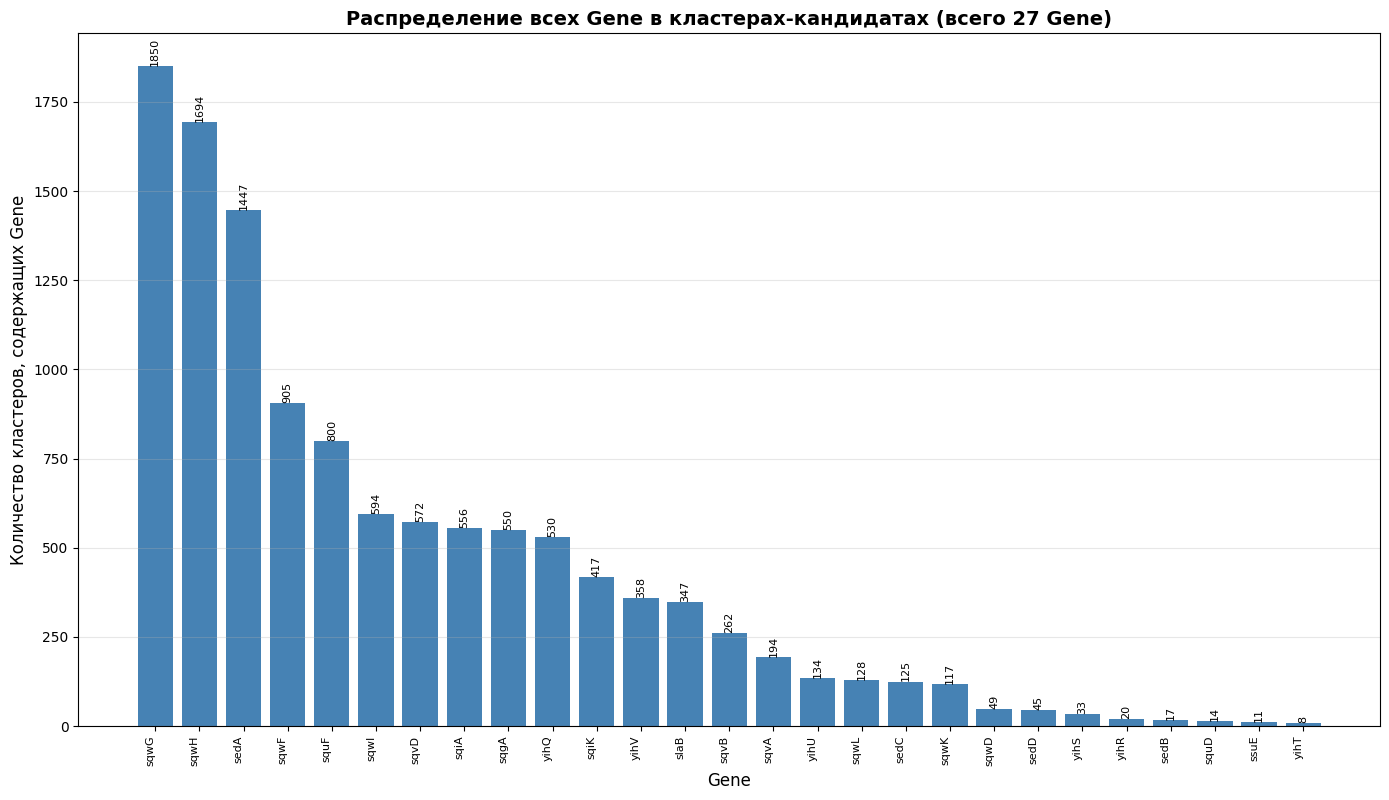

In [30]:
if 'Gene' in candidates.columns:
    # 1. Подсчет частоты каждого Gene
    gene_counts = candidates['Gene'].value_counts().reset_index()
    gene_counts.columns = ['Gene', 'count']

    # Добавляем процент от общего числа
    gene_counts['percentage'] = (gene_counts['count'] / len(candidates) * 100).round(2)

    print(f"\n📊 СТАТИСТИКА ПО GENE В КЛАСТЕРАХ:")
    print(f"   Всего записей с Gene: {candidates['Gene'].notna().sum()}")
    print(f"   Уникальных Gene: {len(gene_counts)}")
    print(f"   Самое частое Gene: {gene_counts.iloc[0]['Gene']} ({gene_counts.iloc[0]['count']} раз)")

    print("   " + "-"*50)
    for i, row in gene_counts.iterrows():
        print(f"   {i+1:2d}. {row['Gene']:<25} {row['count']:>4} раз ({row['percentage']:>5.1f}%)")


    # Сортируем по убыванию для лучшей читаемости
    gene_counts_sorted = gene_counts.sort_values('count', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(14, max(6, len(gene_counts_sorted) * 0.3)))
    bars = plt.bar(range(len(gene_counts_sorted)), gene_counts_sorted['count'], color='steelblue')

    # Настройка графика
    plt.xlabel('Gene', fontsize=12)
    plt.ylabel('Количество кластеров, содержащих Gene', fontsize=12)
    plt.title(f'Распределение всех Gene в кластерах-кандидатах (всего {len(gene_counts_sorted)} Gene)',
              fontsize=14, fontweight='bold')
    plt.xticks(range(len(gene_counts_sorted)), gene_counts_sorted['Gene'],
               rotation=90, ha='right', fontsize=8)
    plt.grid(axis='y', alpha=0.3)

    if len(gene_counts_sorted) <= 30:
        for i, (_, row) in enumerate(gene_counts_sorted.iterrows()):
            plt.text(i, row['count'] + 0.1, str(int(row['count'])),
                     ha='center', va='bottom', fontsize=8, rotation=90)

    plt.tight_layout()
    plt.savefig('all_genes_vertical_barplot.png', dpi=300, bbox_inches='tight')
    plt.show()



In [31]:
# ============================================
# ПОДСЧЕТ РАЗМЕРОВ КЛАСТЕРОВ
# ============================================

# Считаем количество генов в каждом кластере
cluster_sizes = candidates.groupby('new_cluster').size().reset_index(name='n_genes')

# Сортируем по размеру для наглядности
cluster_sizes = cluster_sizes.sort_values('n_genes', ascending=False).reset_index(drop=True)

print(f"\n📊 СТАТИСТИКА ПО РАЗМЕРАМ КЛАСТЕРОВ:")
print(f"   Минимальный размер: {cluster_sizes['n_genes'].min()} генов")
print(f"   Максимальный размер: {cluster_sizes['n_genes'].max()} генов")
print(f"\n   Распределение кластеров по размеру:")
size_distribution = cluster_sizes['n_genes'].value_counts().sort_index()
for size, count in size_distribution.items():
    print(f"      {size} гена/генов: {count} кластеров")




📊 СТАТИСТИКА ПО РАЗМЕРАМ КЛАСТЕРОВ:
   Минимальный размер: 2 генов
   Максимальный размер: 10 генов

   Распределение кластеров по размеру:
      2 гена/генов: 4068 кластеров
      3 гена/генов: 745 кластеров
      4 гена/генов: 180 кластеров
      5 гена/генов: 54 кластеров
      6 гена/генов: 38 кластеров
      7 гена/генов: 16 кластеров
      8 гена/генов: 6 кластеров
      9 гена/генов: 2 кластеров
      10 гена/генов: 1 кластеров


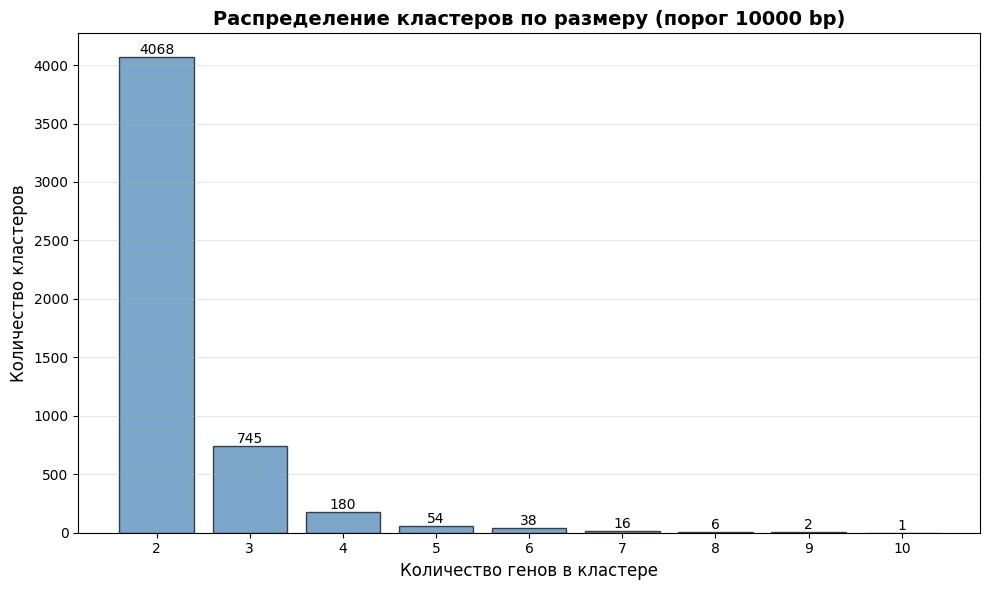

In [32]:
# ============================================
# ПРОСТОЙ БАРПЛОТ
# ============================================

plt.figure(figsize=(10, 6))

# Строим барплот
bars = plt.bar(size_distribution.index, size_distribution.values,
                color='steelblue', edgecolor='black', alpha=0.7)

# Настройка графика
plt.xlabel('Количество генов в кластере', fontsize=12)
plt.ylabel('Количество кластеров', fontsize=12)
plt.title(f'Распределение кластеров по размеру (порог {threshold} bp)',
          fontsize=14, fontweight='bold')
plt.xticks(size_distribution.index)  # показываем все размеры
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на бары
for i, (size, count) in enumerate(size_distribution.items()):
    plt.text(size, count + 0.1, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('cluster_size_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
# ============================================
# ПОИСК КЛАСТЕРА С 10 ГЕНАМИ
# ============================================

# Находим кластеры с 10 генами
cluster_sizes = candidates.groupby('new_cluster').size()
clusters_with_10 = cluster_sizes[cluster_sizes == 10]

print(f"Кластеров с 10 генами: {len(clusters_with_10)}")
print(f"ID кластеров с 10 генами: {list(clusters_with_10.index)}")

# ============================================
# ПРОСМОТР ПЕРВОГО КЛАСТЕРА С 10 ГЕНАМИ
# ============================================

if len(clusters_with_10) > 0:
    # Берем первый кластер с 10 генами
    target_cluster = clusters_with_10.index[0]
    cluster_genes = candidates[candidates['new_cluster'] == target_cluster].sort_values('start')

    print(f"\n" + "="*80)
    print(f"🔬 ДЕТАЛЬНАЯ ИНФОРМАЦИЯ О КЛАСТЕРЕ #{target_cluster} (10 генов)")
    print("="*80)

    # Общая информация
    print(f"\n📍 Общая информация:")
    print(f"   Contig: {cluster_genes.iloc[0]['contig']}")
    print(f"   Количество генов: {len(cluster_genes)}")
    print(f"   Область: {cluster_genes['start'].min():,} - {cluster_genes['end'].max():,} bp")
    print(f"   Длина кластера: {cluster_genes['end'].max() - cluster_genes['start'].min():,} bp")

    # Информация по каждому гену
    print(f"\n🧬 Гены в кластере (в порядке расположения):")
    print("-" * 80)

    for idx, (_, gene) in enumerate(cluster_genes.iterrows(), 1):
        gene_length = gene['end'] - gene['start']
        print(f"\n   Ген {idx}:")
        print(f"      Query: {gene['query']}")
        print(f"      Target: {gene['target']}")
        print(f"      Координаты: {gene['start']:,} - {gene['end']:,} bp (длина: {gene_length:,} bp)")

        if 'Gene' in gene and pd.notna(gene['Gene']):
            print(f"      Gene: {gene['Gene']}")
        if 'Locus' in gene and pd.notna(gene['Locus']):
            print(f"      Locus: {gene['Locus']}")
        if 'product' in gene and pd.notna(gene['product']):
            product = str(gene['product'])[:100]
            print(f"      Продукт: {product}")
        if 'taxonomy' in gene and pd.notna(gene['taxonomy']):
            taxonomy = str(gene['taxonomy'])[:80]
            print(f"      Таксономия: {taxonomy}")

    # Расстояния между генами
    print(f"\n📏 Расстояния между генами:")
    for i in range(len(cluster_genes) - 1):
        dist = cluster_genes.iloc[i+1]['start'] - cluster_genes.iloc[i]['end']
        print(f"   Между геном {i+1} и {i+2}: {dist} bp")

Кластеров с 10 генами: 1
ID кластеров с 10 генами: [29790]

🔬 ДЕТАЛЬНАЯ ИНФОРМАЦИЯ О КЛАСТЕРЕ #29790 (10 генов)

📍 Общая информация:
   Contig: CADBOI010000153.1
   Количество генов: 10
   Область: 3,353 - 29,914 bp
   Длина кластера: 26,561 bp

🧬 Гены в кластере (в порядке расположения):
--------------------------------------------------------------------------------

   Ген 1:
      Query: MCD5344479.1
      Target: GCA_902796335.1_KGNDIB_01089
      Координаты: 3,353 - 4,363 bp (длина: 1,010 bp)
      Gene: sqgA
      Locus: sulfo-EMP
      Продукт: hypothetical protein
      Таксономия: d__Bacteria;p__Spirochaetota;c__Spirochaetia;o__Sphaerochaetales;f__Sphaerochaet

   Ген 2:
      Query: PRO65851.1
      Target: GCA_902796335.1_KGNDIB_01091
      Координаты: 5,740 - 7,068 bp (длина: 1,328 bp)
      Gene: sqvD
      Locus: sulfo-EMP
      Продукт: Sulfoquinovose isomerase
      Таксономия: d__Bacteria;p__Spirochaetota;c__Spirochaetia;o__Sphaerochaetales;f__Sphaerochaet

   Ген 3:


In [34]:
# Сортировка и подготовка
df_v3 = meta_table_filtered.sort_values(['contig', 'start']).reset_index(drop=True)
df_v3['mid'] = (df_v3['start'] + df_v3['end']) / 2
df_v3['distance'] = df_v3.groupby('contig')['mid'].diff()

# Идентификация кластеров
threshold = 5000
df_v3['new_cluster'] = (
    (df_v3['distance'] > threshold) |
    (df_v3['distance'].isna())
).cumsum()

# Отбор кандидатов (кластеры с > 1 гена)
cluster_sizes_v3 = df_v3.groupby('new_cluster').size()
candidate_clusters_v3 = cluster_sizes_v3[cluster_sizes_v3 > 1].index
candidates_v3 = df_v3[df_v3['new_cluster'].isin(candidate_clusters_v3)].copy()

print(f"Кластеров-кандидатов (>1 гена): {len(candidate_clusters_v3)}")
print(f"Всего генов в кандидатах: {len(candidates_v3)}")


Кластеров-кандидатов (>1 гена): 4271
Всего генов в кандидатах: 9740


In [35]:
# Сортировка и подготовка
df_v3 = meta_table_filtered.sort_values(['contig', 'start']).reset_index(drop=True)
df_v3['mid'] = (df_v3['start'] + df_v3['end']) / 2
df_v3['distance'] = df_v3.groupby('contig')['mid'].diff()

# Идентификация кластеров (первичный порог)
threshold = 5000
df_v3['new_cluster'] = (
    (df_v3['distance'] > threshold) |
    (df_v3['distance'].isna())
).cumsum()

# Отбор кандидатов (кластеры с > 1 гена)
cluster_sizes_v3 = df_v3.groupby('new_cluster').size()
candidate_clusters_v3 = cluster_sizes_v3[cluster_sizes_v3 > 1].index
candidates_v3 = df_v3[df_v3['new_cluster'].isin(candidate_clusters_v3)].copy()

print(f"Кластеров-кандидатов после первичной фильтрации: {len(candidate_clusters_v3)}")
print(f"Всего генов в кандидатах: {len(candidates_v3)}")

# ============================================
# РАЗБИЕНИЕ КЛАСТЕРОВ ПО РАССТОЯНИЮ ≤ 1000 bp
# ============================================

max_gap = 1000  # максимальное допустимое расстояние между концом гена и началом следующего

# Создаем новый столбец для финальных кластеров
df_v3['final_cluster'] = df_v3['new_cluster']

# Счетчик для новых кластеров
new_cluster_counter = df_v3['final_cluster'].max() + 1

# Разбиваем кластеры
for cluster_id in candidates_v3['new_cluster'].unique():
    # Получаем гены в этом кластере
    cluster_mask = df_v3['new_cluster'] == cluster_id
    cluster_genes = df_v3[cluster_mask].sort_values('start')

    if len(cluster_genes) > 1:
        current_cluster_id = cluster_id
        previous_end = cluster_genes.iloc[0]['end']

        for i in range(1, len(cluster_genes)):
            current_start = cluster_genes.iloc[i]['start']
            gap = current_start - previous_end

            # Если расстояние больше max_gap, начинаем новый кластер
            if gap > max_gap:
                new_cluster_counter += 1
                current_cluster_id = new_cluster_counter

            # Присваиваем ID финального кластера
            idx = cluster_genes.index[i]
            df_v3.loc[idx, 'final_cluster'] = current_cluster_id

            previous_end = cluster_genes.iloc[i]['end']

# Отбор финальных кандидатов (кластеры с > 1 гена)
final_cluster_sizes = df_v3.groupby('final_cluster').size()
final_candidate_clusters = final_cluster_sizes[final_cluster_sizes > 1].index
candidates_final = df_v3[df_v3['final_cluster'].isin(final_candidate_clusters)].copy()

print(f"\n📊 Результаты ПОСЛЕ разбиения (расстояние между генами ≤ {max_gap} bp):")
print(f"   Кластеров-кандидатов: {len(final_candidate_clusters)}")
print(f"   Всего генов в кандидатах: {len(candidates_final)}")

# ============================================
# СРАВНЕНИЕ
# ============================================

print(f"\n📊 Сравнение:")
print(f"   До разбиения: {len(candidate_clusters_v3)} кластеров, {len(candidates_v3)} генов")
print(f"   После разбиения: {len(final_candidate_clusters)} кластеров, {len(candidates_final)} генов")
print(f"   Изменение: {len(final_candidate_clusters) - len(candidate_clusters_v3):+d} кластеров")


Кластеров-кандидатов после первичной фильтрации: 4271
Всего генов в кандидатах: 9740

📊 Результаты ПОСЛЕ разбиения (расстояние между генами ≤ 1000 bp):
   Кластеров-кандидатов: 3331
   Всего генов в кандидатах: 7365

📊 Сравнение:
   До разбиения: 4271 кластеров, 9740 генов
   После разбиения: 3331 кластеров, 7365 генов
   Изменение: -940 кластеров


In [40]:
df_v3.head(15)

,MAG,query,target,identity,aln_len,evalue,bitscore,product,contig,start,...,Organism name,Locus,Gene,Function,PFAM ID,Reference,mid,distance,new_cluster,final_cluster
0,GCA_902754905.1,WP_017967310.1,GCA_902754905.1_MPLGKE_00215,35.0,243,1.330000e-28,112.0,3-oxoacyl-[acyl-carrier-protein] reductase,CACVKZ010000009.1,11161,...,Rhizobium leguminosarum bv. trifolii SRDI565,sulfo-ED,sedA,SQ dehydrogenase,PF13561,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...,11532.5,NaN,1,1
1,GCA_902754905.1,AAK90113.2,GCA_902754905.1_MPLGKE_00263,29.0,145,1.550000e-05,47.4,hypothetical protein,CACVKZ010000010.1,39090,...,Agrobacterium fabrum str. C58,sulfo- ASMO,ssuE,flavin reductase,PF01613,https://doi.org/10.1073/pnas.2116022119,39344.5,NaN,2,2
2,GCA_902754905.1,EJF39089.1,GCA_902754905.1_MPLGKE_00351,41.1,129,5.240000e-24,95.1,Ribose 5-phosphate isomerase B,CACVKZ010000015.1,4930,...,Clostridium sp. MSTE9,sulfo-TK,sqwI,SE isomerase,PF02502,https://zhaogroup.chbe.illinois.edu/publicatio...,5156.0,NaN,3,3
3,GCA_902754905.1,WP_017967310.1,GCA_902754905.1_MPLGKE_00362,28.9,242,3.770000e-13,71.2,3-oxoacyl-[acyl-carrier-protein] reductase,CACVKZ010000015.1,15523,...,Rhizobium leguminosarum bv. trifolii SRDI565,sulfo-ED,sedA,SQ dehydrogenase,PF13561,https://pmc.ncbi.nlm.nih.gov/articles/pmid/324...,15887.0,10731.0,4,4
4,GCA_902754905.1,EJF39103.1,GCA_902754905.1_MPLGKE_00382,26.7,375,2.830000e-32,132.0,Aldehyde-alcohol dehydrogenase,CACVKZ010000016.1,9684,...,Clostridium sp. MSTE9,sulfo-TK,sqwF,SA reductase,PF00465,https://zhaogroup.chbe.illinois.edu/publicatio...,11006.5,NaN,5,5
5,GCA_902754905.1,AAK90112.1,GCA_902754905.1_MPLGKE_00405,27.1,299,3.180000e-16,81.6,hypothetical protein,CACVKZ010000018.1,2887,...,Agrobacterium fabrum str. C58,sulfo- ASMO,squF,glucose-6-dehydrogenase,PF00248,https://doi.org/10.1073/pnas.2116022119,3345.5,NaN,6,6
6,GCA_902754905.1,EJF39090.1,GCA_902754905.1_MPLGKE_00494,33.2,292,1.670000e-35,137.0,hypothetical protein,CACVKZ010000025.1,12297,...,Clostridium sp. MSTE9,sulfo-TK,sqwH,SF transketolase,"PF02779, PF02780",https://zhaogroup.chbe.illinois.edu/publicatio...,12929.5,NaN,7,7
7,GCA_902754905.1,EJF39099.1,GCA_902754905.1_MPLGKE_00842,25.7,284,1.820000e-07,56.6,Transketolase-like pyrimidine-binding domain-c...,CACVKZ010000053.1,5056,...,Clostridium sp. MSTE9,sulfo-TK,sqwG,SF transketolase,PF00456,https://zhaogroup.chbe.illinois.edu/publicatio...,6176.0,NaN,8,8
8,GCA_902754905.1,PRO65852.1,GCA_902754905.1_MPLGKE_00872,23.2,241,2.470000e-09,63.5,Pyrophosphate--fructose 6-phosphate 1-phosphot...,CACVKZ010000057.1,2424,...,Alkalicoccus urumqiensis BZ-SZ-XJ18,sulfo-EMP,sqiK,SF kinase,PF00365,https://zhaogroup.chbe.illinois.edu/publicatio...,3263.5,NaN,9,9
9,GCA_902754905.1,EJF39103.1,GCA_902754905.1_MPLGKE_00892,27.2,323,1.090000e-26,114.0,Iron-containing alcohol dehydrogenase,CACVKZ010000059.1,4710,...,Clostridium sp. MSTE9,sulfo-TK,sqwF,SA reductase,PF00465,https://zhaogroup.chbe.illinois.edu/publicatio...,5317.0,NaN,10,10


In [ ]:
df_v3.to_csv("meta_table_clusters.tsv", sep="\t", index=False)

In [41]:
candidates_final.head(15)

,MAG,query,target,identity,aln_len,evalue,bitscore,product,contig,start,...,Organism name,Locus,Gene,Function,PFAM ID,Reference,mid,distance,new_cluster,final_cluster
13,GCA_902754875.1,EJF39103.1,GCA_902754875.1_KMPMIM_00214,34.9,364,5.160000e-64,212.0,hypothetical protein,CACVLA010000002.1,26588,...,Clostridium sp. MSTE9,sulfo-TK,sqwF,SA reductase,PF00465,https://zhaogroup.chbe.illinois.edu/publicatio...,27136.5,NaN,14,14
14,GCA_902754875.1,EJF39089.1,GCA_902754875.1_KMPMIM_00215,57.6,85,4.140000e-28,103.0,hypothetical protein,CACVLA010000002.1,27675,...,Clostridium sp. MSTE9,sulfo-TK,sqwI,SE isomerase,PF02502,https://zhaogroup.chbe.illinois.edu/publicatio...,27803.5,667.0,14,14
15,GCA_902754875.1,EJF39090.1,GCA_902754875.1_KMPMIM_00216,55.1,254,7.350000e-88,267.0,hypothetical protein,CACVLA010000002.1,27946,...,Clostridium sp. MSTE9,sulfo-TK,sqwH,SF transketolase,"PF02779, PF02780",https://zhaogroup.chbe.illinois.edu/publicatio...,28326.5,523.0,14,14
29,GCA_902754875.1,EJF39099.1,GCA_902754875.1_KMPMIM_01959,50.6,265,7.450000e-85,259.0,Transketolase 1,CACVLA010000043.1,5168,...,Clostridium sp. MSTE9,sulfo-TK,sqwG,SF transketolase,PF00456,https://zhaogroup.chbe.illinois.edu/publicatio...,5590.5,NaN,27,27
30,GCA_902754875.1,EJF39090.1,GCA_902754875.1_KMPMIM_01960,46.2,303,6.760000e-80,249.0,1-deoxy-D-xylulose-5-phosphate synthase,CACVLA010000043.1,6015,...,Clostridium sp. MSTE9,sulfo-TK,sqwH,SF transketolase,"PF02779, PF02780",https://zhaogroup.chbe.illinois.edu/publicatio...,6488.5,898.0,27,27
38,GCA_902754935.1,EJF39099.1,GCA_902754935.1_FMFMNE_00870,40.5,269,6.600000e-61,198.0,Apulose-4-phosphate transketolase subunit A,CACVLC010000009.1,56629,...,Clostridium sp. MSTE9,sulfo-TK,sqwG,SF transketolase,PF00456,https://zhaogroup.chbe.illinois.edu/publicatio...,57063.5,28373.5,35,35
39,GCA_902754935.1,EJF39090.1,GCA_902754935.1_FMFMNE_00871,35.1,299,1.840000e-45,160.0,Transketolase,CACVLC010000009.1,57505,...,Clostridium sp. MSTE9,sulfo-TK,sqwH,SF transketolase,"PF02779, PF02780",https://zhaogroup.chbe.illinois.edu/publicatio...,57963.5,900.0,35,35
44,GCA_902754935.1,EJF39099.1,GCA_902754935.1_FMFMNE_01196,36.3,259,3.600000e-41,154.0,Transketolase-like pyrimidine-binding domain-c...,CACVLC010000012.1,146804,...,Clostridium sp. MSTE9,sulfo-TK,sqwG,SF transketolase,PF00456,https://zhaogroup.chbe.illinois.edu/publicatio...,147811.5,NaN,38,38
45,GCA_902754935.1,EJF39089.1,GCA_902754935.1_FMFMNE_01197,34.9,126,8.110000e-11,60.8,Ribose 5-phosphate isomerase B,CACVLC010000012.1,148819,...,Clostridium sp. MSTE9,sulfo-TK,sqwI,SE isomerase,PF02502,https://zhaogroup.chbe.illinois.edu/publicatio...,149042.0,1230.5,38,38
64,GCA_902755005.1,EJF39099.1,GCA_902755005.1_CDDBCO_01033,47.6,269,1.780000e-82,253.0,Transketolase 1,CACVLG010000008.1,49913,...,Clostridium sp. MSTE9,sulfo-TK,sqwG,SF transketolase,PF00456,https://zhaogroup.chbe.illinois.edu/publicatio...,50331.0,NaN,56,56


In [ ]:
candidates_final.to_csv("meta_table_candidates.tsv", sep="\t", index=False)

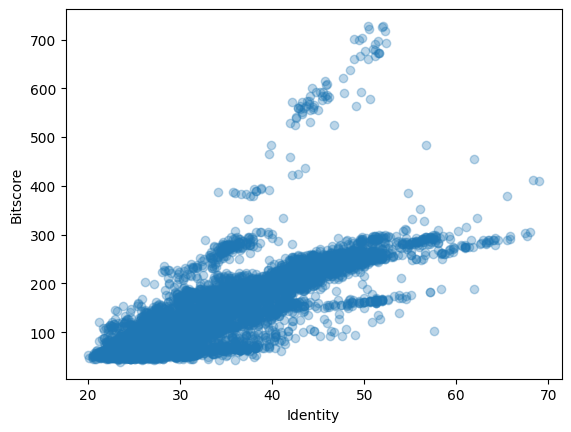

In [42]:
import numpy as np
import matplotlib.pyplot as plt

df = candidates_final.copy()
df['log_evalue'] = -np.log10(df['evalue'])

plt.scatter(df['identity'], df['bitscore'], alpha=0.3)
plt.xlabel('Identity')
plt.ylabel('Bitscore')
plt.show()

In [60]:
# Всего точек до фильтрации
total_before = len(candidates_final)

# Применённый фильтр
df_q = candidates_final[
    (candidates_final['evalue'] < 1e-5) &
    (candidates_final['bitscore'] > 50)
].copy()

# Всего точек после фильтрации
total_after = len(df_q)

# Сколько отброшено
dropped = total_before - total_after
dropped_percent = dropped / total_before * 100

print(f"Всего точек до фильтрации: {total_before}")
print(f"Всего точек после фильтрации: {total_after}")
print(f"Отброшено: {dropped} ({dropped_percent:.1f}%)")

Всего точек до фильтрации: 7365
Всего точек после фильтрации: 7101
Отброшено: 264 (3.6%)


In [45]:
# сначала собираем локусы
loci = df_q.groupby('final_cluster').agg({
    'Gene': lambda x: ','.join(sorted(set(x.dropna())))
}).reset_index()

In [ ]:
core_genes = {
    'EMP': {'yihV', 'yihT', 'sqiK', 'sqiA'}, 
    'TK': {'sqwG', 'sqwH', 'sqwI', 'yihS'}, 
    'TAL': {'sqvA', 'yihS'}, 
    'ED': {'yihQ', 'sedA', 'sedC', 'sedD'}
}

for pathway, genes in core_genes.items():
    loci[f'{pathway}_count'] = loci['Gene'].apply(
        lambda x: len(set(x.split(',')) & genes)
    )

filtered_loci = loci[
    loci[[f'{p}_count' for p in core_genes]].max(axis=1) >= 2
]

df_final = df_q[
    df_q['final_cluster'].isin(filtered_loci['final_cluster'])
]

In [61]:
total_before = len(df_q)
total_after = len(df_final)
dropped = total_before - total_after
dropped_percent = dropped / total_before * 100

print(f"Всего хитов перед фильтром по core-генам: {total_before}")
print(f"Всего хитов после фильтра: {total_after}")
print(f"Отброшено: {dropped} ({dropped_percent:.1f}%)")

Всего хитов перед фильтром по core-генам: 7101
Всего хитов после фильтра: 4191
Отброшено: 2910 (41.0%)


In [62]:
clusters_before = df_q['final_cluster'].nunique()
clusters_after = df_final['final_cluster'].nunique()

print(f"Локусов перед фильтром: {clusters_before}")
print(f"Локусов после фильтра: {clusters_after}")
print(f"Потеря локусов: {clusters_before - clusters_after}")

Локусов перед фильтром: 3326
Локусов после фильтра: 1833
Потеря локусов: 1493


In [63]:
df_plot = df_final.copy()
df_plot['log_evalue'] = -np.log10(df_plot['evalue'])

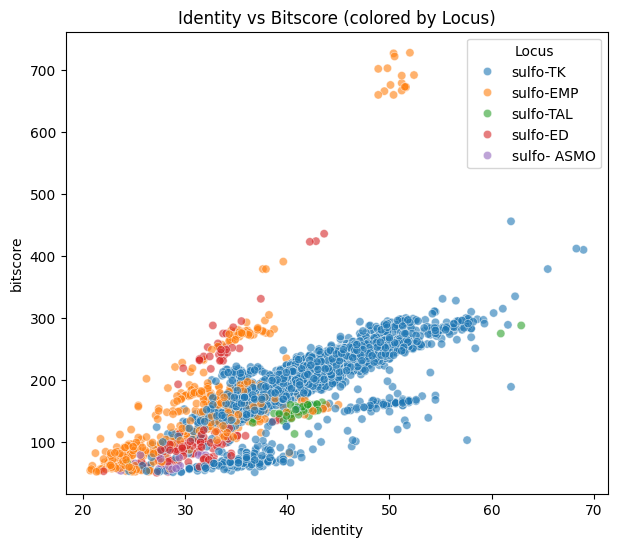

In [65]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    data=df_plot,
    x='identity',
    y='bitscore',
    hue='Locus',
    alpha=0.6
)

plt.title('Identity vs Bitscore (colored by Locus)')
plt.show()

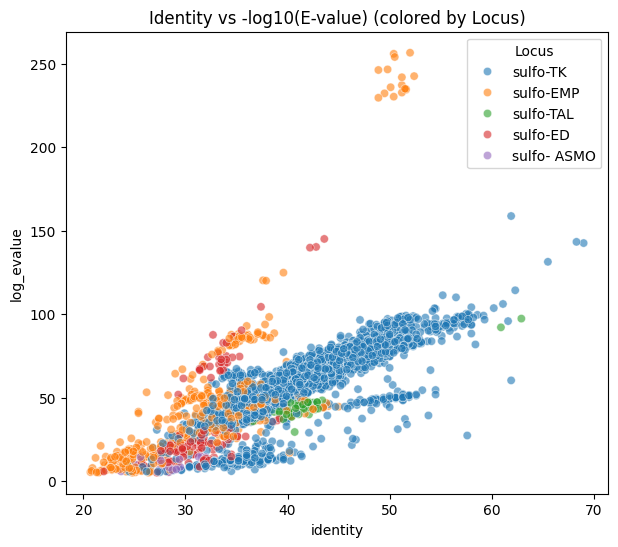

In [58]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    data=df_plot,
    x='identity',
    y='log_evalue',
    hue='Locus',
    alpha=0.6
)

plt.title('Identity vs -log10(E-value) (colored by Locus)')
plt.show()

/tmp/ipykernel_6053/3888847596.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


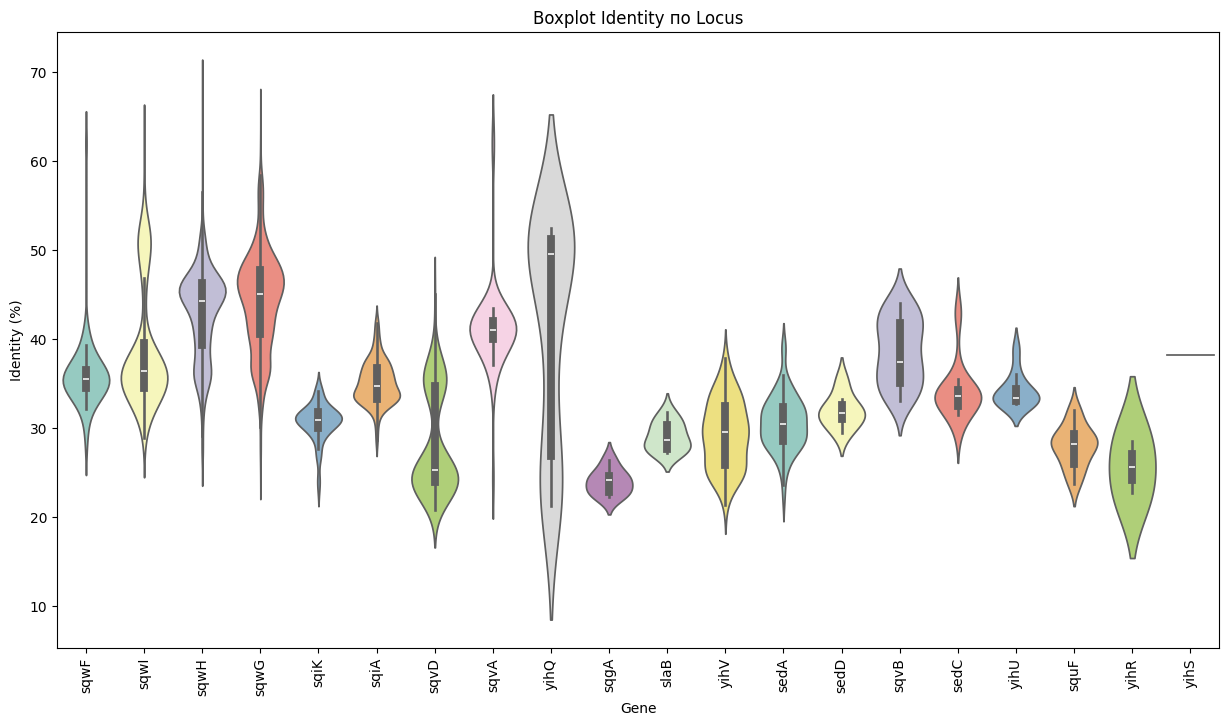

In [80]:
plt.figure(figsize=(15,8))
sns.violinplot(
    data=df_final,
    x='Gene',
    y='identity',
    palette='Set3'
)
plt.xticks(rotation=90)
plt.ylabel('Identity (%)')
plt.title('Boxplot Identity по Locus')
plt.show()

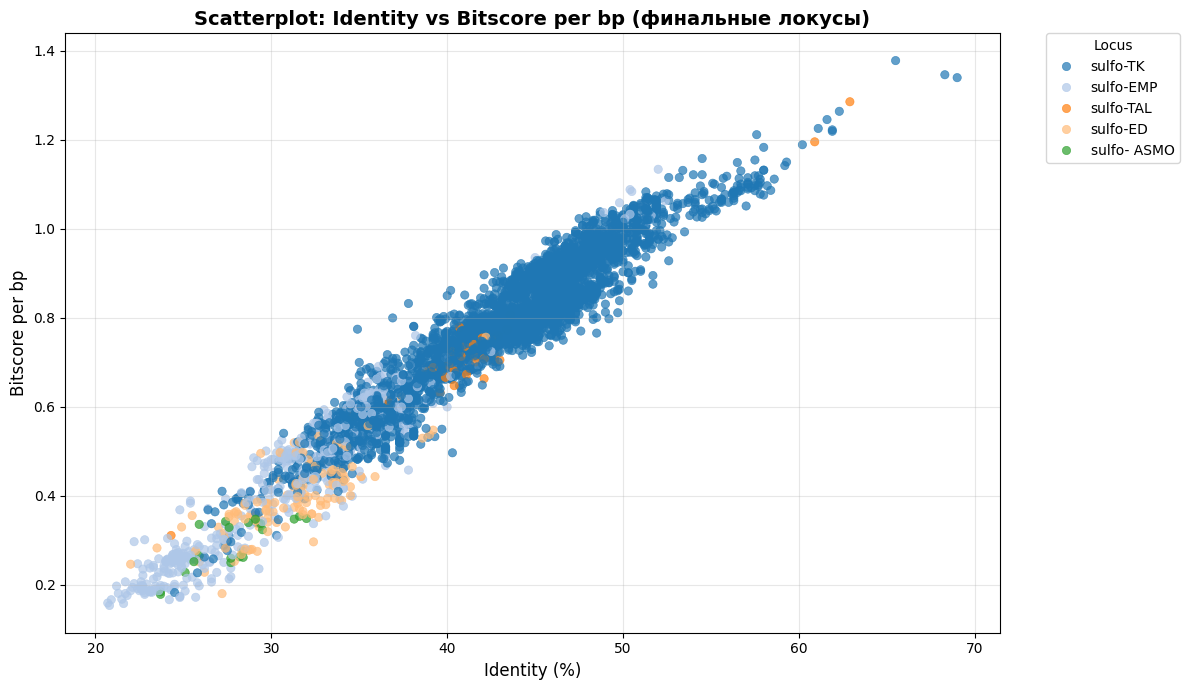

In [67]:
# Добавляем нормированный bitscore
df_final['bitscore_per_bp'] = df_final['bitscore'] / df_final['aln_len']

# Строим scatterplot
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_final,
    x='identity',
    y='bitscore_per_bp',
    hue='Locus',
    palette='tab20',
    alpha=0.7,
    edgecolor=None
)

plt.xlabel('Identity (%)', fontsize=12)
plt.ylabel('Bitscore per bp', fontsize=12)
plt.title('Scatterplot: Identity vs Bitscore per bp (финальные локусы)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title='Locus')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [76]:
# --- Определяем веса для генов (core = 1, вспомогательные = 0.5) ---
core_gene_weights = {
    'yihQ': 1.0, 'sqgA': 1.0,
    'sqwG': 0.9, 'sqwH': 0.9, 'sqwI': 0.9,
    'yihV': 0.8, 'sqiK': 0.8, 'yihT': 0.8, 'sqiA': 0.8,
    'yihS': 0.8, 'sqvA': 0.8, 'sedA': 1.0, 'sedC': 0.9, 'sedD': 0.9
}

# Группируем df_final по Locus и final_cluster
df_final_locus_scores = df_final.groupby(['Locus', 'final_cluster']).agg({
    'Gene': lambda x: ','.join(sorted(set(','.join(x).split(',')))),  # все гены в кластере
    'identity': 'mean',   # среднее identity
    'bitscore': 'mean',   # среднее bitscore
    'evalue': 'mean'      # среднее evalue
}).reset_index()

# --- Вычислим простую метрику score ---
# Например: score = mean_identity * mean_bitscore / (1 + log10(evalue))
import numpy as np

df_final_locus_scores['score'] = (
    df_final_locus_scores['identity'] * df_final_locus_scores['bitscore'] /
    (1 + -np.log10(df_final_locus_scores['evalue'].replace(0, 1e-300)))
)

# Сохраняем
df_final_locus_scores.to_csv('df_final_locus_scores.csv', index=False)

df_final_locus_scores.head()

,Locus,final_cluster,Gene,identity,bitscore,evalue,score
0,sulfo- ASMO,6314,squF,23.7,58.5,3.270000e-08,163.391409
1,sulfo- ASMO,7381,squF,28.2,77.4,1.250000e-14,146.458218
2,sulfo- ASMO,7783,squF,29.3,63.5,6.150000e-10,182.208133
3,sulfo- ASMO,7843,squF,27.7,57.8,5.760000e-08,194.313361
4,sulfo- ASMO,8155,squF,25.9,55.8,2.500000e-07,190.108997


/tmp/ipykernel_6053/131065856.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


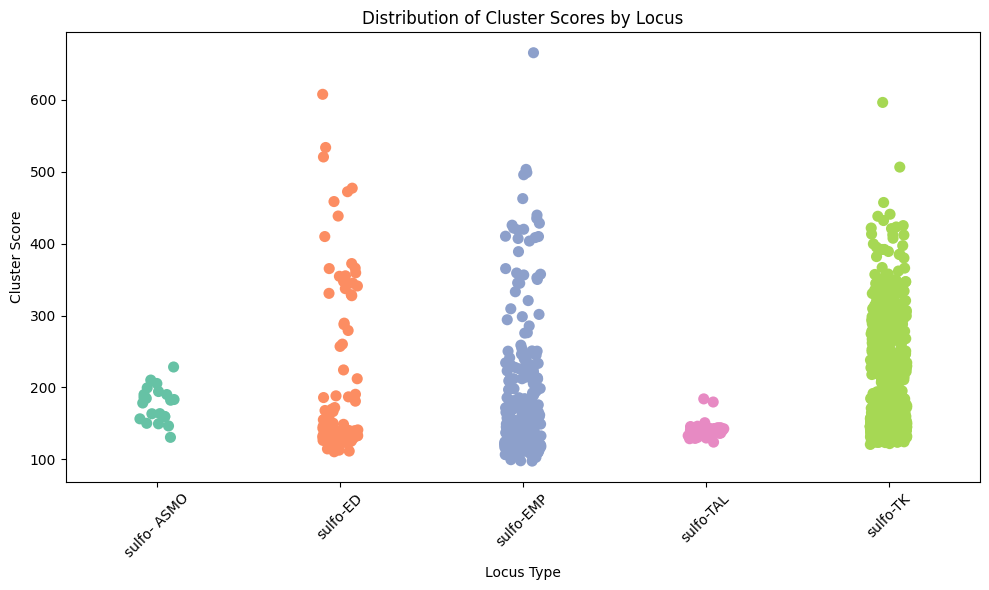

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.stripplot(
    data=df_final_locus_scores,
    x='Locus',
    y='score',
    jitter=True,
    size=8,
    palette='Set2'
)
plt.ylabel('Cluster Score')
plt.xlabel('Locus Type')
plt.title('Distribution of Cluster Scores by Locus')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [82]:
# Добавляем булевы флаги на основе наличия core-генов
filtered_loci['EMP_min'] = filtered_loci['EMP_count'] >= 2
filtered_loci['TK_min']  = filtered_loci['TK_count']  >= 2
filtered_loci['TAL_min'] = filtered_loci['TAL_count'] >= 2
filtered_loci['ED_min']  = filtered_loci['ED_count']  >= 2

# Определяем класс локуса
def get_locus_class(row):
    classes = []
    if row['EMP_min']: classes.append('sulfo-EMP')
    if row['TK_min']:  classes.append('sulfo-TK')
    if row['TAL_min']: classes.append('sulfo-TAL')
    if row['ED_min']:  classes.append('sulfo-ED')
    return ','.join(classes)

filtered_loci['Locus'] = filtered_loci.apply(get_locus_class, axis=1)

In [83]:
# Простейший score = сумма bitscore / количество генов
filtered_loci['score'] = filtered_loci['bitscore'] / filtered_loci['aln_len']  # нормировка на длину

KeyError: 'bitscore'